# Contact Map Visualization

Compare model-generated vs ground-truth residue-residue contact maps as heatmaps.
Downloads a PDB structure, computes ground-truth atomic contacts, then generates
contacts from a trained exp4 checkpoint with varying prefix sizes.

In [14]:
# Config
CHECKPOINT_PATH = "../../outputs/exp4"  # auto-finds latest checkpoint-* subdir
PDB_ID = "1QYS"
CONTACT_DISTANCE_CUTOFF = 4.0  # Angstroms, for heavy atom contacts
MAX_NEW_TOKENS = 3440
PREFIX_SIZES = [0, 5, 10, 20]
DEVICE = "cuda"

In [15]:
# Download & parse PDB structure
import tempfile
import numpy as np
from biotite.database import rcsb
from biotite.structure.io import pdbx
from biotite.structure import filter_amino_acids

path = rcsb.fetch(PDB_ID, "cif", tempfile.gettempdir())
cif = pdbx.CIFFile.read(path)
atoms = pdbx.get_structure(cif.block, model=1)

# First chain, amino acids only, heavy atoms only
first_chain = atoms.chain_id[0]
chain_atoms = atoms[(atoms.chain_id == first_chain) & filter_amino_acids(atoms) & (atoms.element != "H")]

# Build residue list (1-indexed positions)
res_ids = chain_atoms.res_id
unique_res = sorted(set(res_ids))
res_id_to_pos = {rid: i + 1 for i, rid in enumerate(unique_res)}  # 1-indexed
sequence = [chain_atoms[chain_atoms.res_id == rid].res_name[0] for rid in unique_res]
seq_len = len(sequence)
print(f"Protein {PDB_ID}: {seq_len} residues, chain {first_chain}")
print(f"Sequence: {' '.join(sequence[:10])}...")

Protein 1QYS: 92 residues, chain A
Sequence: ASP ILE GLN VAL GLN VAL ASN ILE ASP ASP...


In [16]:
# Compute ground-truth contacts
from scipy.spatial import KDTree
from experiments.exp4_contact_prediction.src.data import VALID_ATOMS

coords = chain_atoms.coord
atom_names = chain_atoms.atom_name
atom_res_ids = chain_atoms.res_id

# Filter to atoms known in the vocabulary
known_atom_set = set(VALID_ATOMS.get(sequence[0], set()))  # just for reference
all_known_atoms = set()
for aa in VALID_ATOMS:
    all_known_atoms.update(VALID_ATOMS[aa])

# Use KDTree for efficient neighbor search
tree = KDTree(coords)
pairs = tree.query_pairs(r=CONTACT_DISTANCE_CUTOFF)

gt_contacts = []  # (pos1, pos2, atom1, atom2)
for i, j in pairs:
    ri, rj = atom_res_ids[i], atom_res_ids[j]
    pi, pj = res_id_to_pos.get(ri), res_id_to_pos.get(rj)
    if pi is None or pj is None:
        continue
    if abs(pi - pj) < 2:
        continue
    ai, aj = str(atom_names[i]), str(atom_names[j])
    if ai not in all_known_atoms or aj not in all_known_atoms:
        continue
    # Validate atoms for their respective amino acids
    aa_i = sequence[pi - 1]
    aa_j = sequence[pj - 1]
    if aa_i not in VALID_ATOMS or ai not in VALID_ATOMS[aa_i]:
        continue
    if aa_j not in VALID_ATOMS or aj not in VALID_ATOMS[aa_j]:
        continue
    # Canonical ordering: larger position first for the pair with larger separation
    if pi > pj:
        gt_contacts.append((pj, pi, aj, ai))
    else:
        gt_contacts.append((pi, pj, ai, aj))

# Deduplicate
gt_contacts = sorted(set(gt_contacts), key=lambda c: (-abs(c[0] - c[1]), c[0], c[1], c[2], c[3]))
print(f"Ground-truth contacts: {len(gt_contacts)}")
print(f"First 5: {gt_contacts[:5]}")

# Build the document prompt
seq_tokens = " ".join(f"<{aa}>" for aa in sequence)
base_prompt = f"<deterministic-positives-only> <begin_sequence> {seq_tokens} <begin_contacts>"
print(f"\nPrompt length: {len(base_prompt.split())} tokens")

Ground-truth contacts: 860
First 5: [(1, 51, 'O', 'O'), (2, 51, 'C', 'O'), (2, 51, 'CA', 'O'), (43, 92, 'O', 'CB'), (43, 92, 'O', 'CD2')]

Prompt length: 95 tokens


In [17]:
#VALID_ATOMS

In [18]:
# Load model & tokenizer
import glob
import torch
from pathlib import Path
from transformers import LlamaForCausalLM
from experiments.exp4_contact_prediction.src.train import create_tokenizer, parse_generated_contacts

# Find latest checkpoint
ckpt_base = Path(CHECKPOINT_PATH)
ckpt_dirs = sorted(ckpt_base.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[1]))
if ckpt_dirs:
    ckpt_path = ckpt_dirs[-1]
else:
    ckpt_path = ckpt_base  # fallback: treat base as the checkpoint
print(f"Loading checkpoint: {ckpt_path}")

tokenizer = create_tokenizer()
model = LlamaForCausalLM.from_pretrained(str(ckpt_path), torch_dtype=torch.bfloat16)
model = model.to(DEVICE).eval()
print(f"Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters")

Loading checkpoint: ../../outputs/exp4/checkpoint-29500


Loading weights: 100%|██████████| 147/147 [00:00<00:00, 361.67it/s, Materializing param=model.norm.weight]                              


Model loaded: 984,475,648 parameters


In [19]:
# Generate contacts for each prefix size
end_token_id = tokenizer.convert_tokens_to_ids("<end>")
generated_contacts = {}  # prefix_size -> list of contacts

for n_prefix in PREFIX_SIZES:
    # Build prompt with prefix ground-truth contacts
    if n_prefix > 0 and gt_contacts:
        prefix_toks = []
        for p1, p2, a1, a2 in gt_contacts[:n_prefix]:
            prefix_toks.extend([f"<p{p1}>", f"<p{p2}>", f"<{a1}>", f"<{a2}>"])
        prompt = base_prompt + " " + " ".join(prefix_toks)
    else:
        prompt = base_prompt

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=8192)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=end_token_id,
        )

    gen_ids = outputs[0][inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=False)
    contacts, valid_grammar = parse_generated_contacts(gen_text.split())

    # Prepend the prefix contacts
    if n_prefix > 0:
        contacts = list(gt_contacts[:n_prefix]) + list(contacts)

    generated_contacts[n_prefix] = contacts
    print(f"Prefix {n_prefix:2d}: {len(contacts):4d} contacts, valid_grammar={valid_grammar}")

Prefix  0:  215 contacts, valid_grammar=True
Prefix  5:  215 contacts, valid_grammar=True
Prefix 10:  151 contacts, valid_grammar=True
Prefix 20:  159 contacts, valid_grammar=True


In [20]:
# Build contact matrices (separate prefix vs generated)
def contacts_to_matrix(contacts, seq_len):
    """Convert contact list to symmetric NxN binary matrix."""
    matrix = np.zeros((seq_len, seq_len), dtype=np.float32)
    for p1, p2, a1, a2 in contacts:
        if 1 <= p1 <= seq_len and 1 <= p2 <= seq_len:
            matrix[p1 - 1, p2 - 1] = 1
            matrix[p2 - 1, p1 - 1] = 1
    return matrix

gt_matrix = contacts_to_matrix(gt_contacts, seq_len)
gt_pair_set = {(min(c[0], c[1]), max(c[0], c[1])) for c in gt_contacts}

# For each prefix size, build separate prefix and generated-only matrices
prefix_matrices = {}
gen_only_matrices = {}
gen_accuracy = {}  # prefix_size -> {precision, recall, ...}

for n_prefix, contacts in generated_contacts.items():
    prefix_contacts = contacts[:n_prefix] if n_prefix > 0 else []
    gen_only_contacts = contacts[n_prefix:] if n_prefix > 0 else contacts

    prefix_matrices[n_prefix] = contacts_to_matrix(prefix_contacts, seq_len)
    gen_only_matrices[n_prefix] = contacts_to_matrix(gen_only_contacts, seq_len)

    # Compute accuracy at the residue-pair level for generated-only contacts
    gen_pairs = {(min(c[0], c[1]), max(c[0], c[1])) for c in gen_only_contacts}
    n_gen = len(gen_pairs)
    n_correct = len(gen_pairs & gt_pair_set)
    precision = n_correct / n_gen if n_gen > 0 else 0.0
    recall = n_correct / len(gt_pair_set) if gt_pair_set else 0.0
    gen_accuracy[n_prefix] = {
        "n_gen_pairs": n_gen,
        "n_correct": n_correct,
        "precision": precision,
        "recall": recall,
    }

print(f"Ground truth: {len(gt_pair_set)} unique residue pairs")
for k, acc in gen_accuracy.items():
    print(f"Prefix {k:2d}: {acc['n_gen_pairs']} gen pairs, "
          f"{acc['n_correct']} correct, "
          f"precision={acc['precision']:.1%}, recall={acc['recall']:.1%}")

Ground truth: 250 unique residue pairs
Prefix  0: 215 gen pairs, 117 correct, precision=54.4%, recall=46.8%
Prefix  5: 210 gen pairs, 111 correct, precision=52.9%, recall=44.4%
Prefix 10: 141 gen pairs, 93 correct, precision=66.0%, recall=37.2%
Prefix 20: 139 gen pairs, 90 correct, precision=64.7%, recall=36.0%


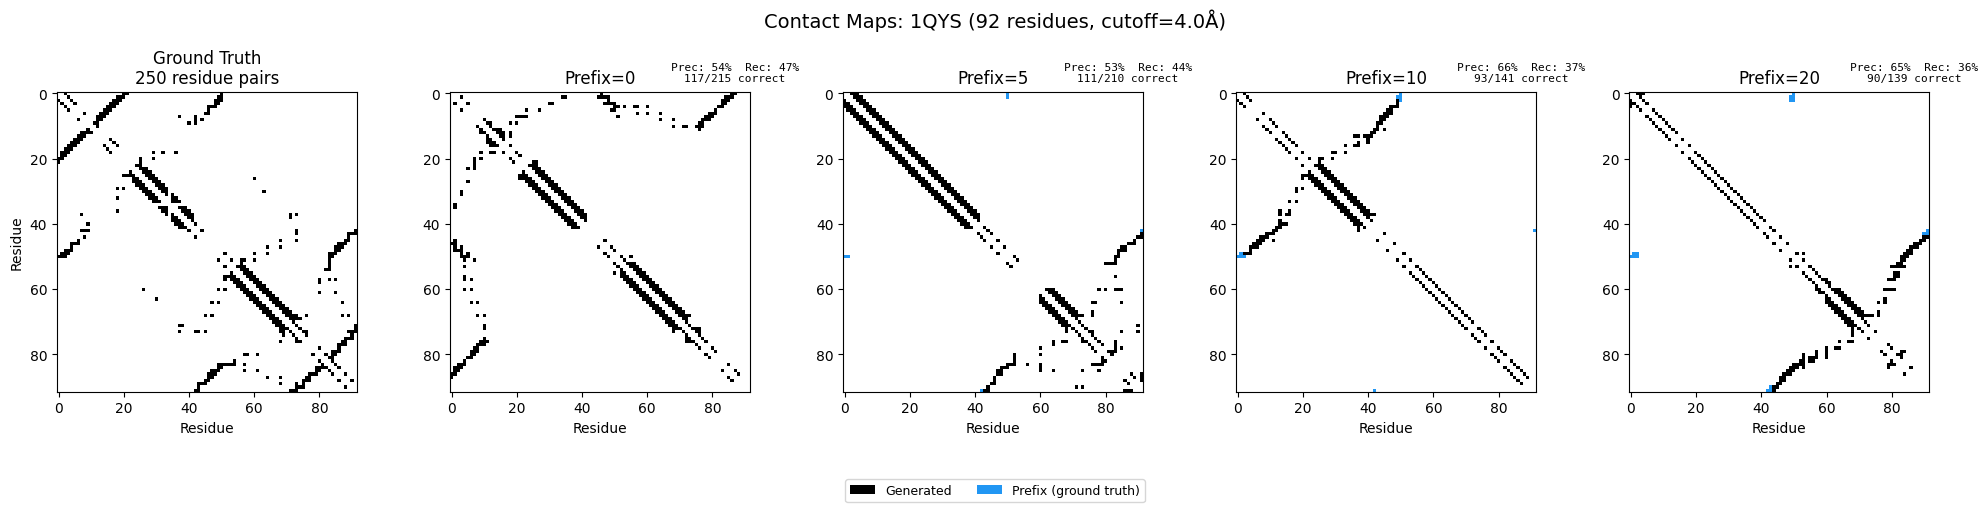

In [25]:
# Plot heatmaps with prefix contacts in a different color
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

n_cols = 1 + len(PREFIX_SIZES)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4.8), squeeze=False)
axes = axes[0]

# Color scheme: 0=white (no contact), 1=black (generated), 2=blue (prefix/ground-truth)
cmap_gt = ListedColormap(["white", "black"])
cmap_gen = ListedColormap(["white", "black", "#2196F3"])  # 0=white, 1=generated, 2=prefix

# Ground truth
axes[0].imshow(gt_matrix, cmap=cmap_gt, vmin=0, vmax=1, origin="upper", aspect="equal")
n_gt_pairs = len(gt_pair_set)
axes[0].set_title(f"Ground Truth\n{n_gt_pairs} residue pairs")
axes[0].set_xlabel("Residue")
axes[0].set_ylabel("Residue")

# Generated panels
for i, n_prefix in enumerate(PREFIX_SIZES):
    ax = axes[i + 1]
    acc = gen_accuracy[n_prefix]

    # Build a combined matrix: 0=empty, 1=generated, 2=prefix
    combined = np.zeros((seq_len, seq_len), dtype=np.float32)
    combined[gen_only_matrices[n_prefix] > 0] = 1
    combined[prefix_matrices[n_prefix] > 0] = 2  # prefix overwrites generated

    ax.imshow(combined, cmap=cmap_gen, vmin=0, vmax=2, origin="upper", aspect="equal")

    title = f"Prefix={n_prefix}"
    ax.set_title(title)
    ax.set_xlabel("Residue")

    # Annotate with accuracy stats
    stats_text = (
        f"Prec: {acc['precision']:.0%}  Rec: {acc['recall']:.0%}\n"
        f"{acc['n_correct']}/{acc['n_gen_pairs']} correct"
    )
    ax.text(
        0.95, 1.1, stats_text,
        transform=ax.transAxes, ha="center", va="top",
        fontsize=8, fontfamily="monospace",
    )

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="black", label="Generated"),
    Patch(facecolor="#2196F3", label="Prefix (ground truth)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    f"Contact Maps: {PDB_ID} ({seq_len} residues, cutoff={CONTACT_DISTANCE_CUTOFF}\u00c5)",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()